# " Ride Demand Forecasting Data Prep Engine " 

#### 🎯 Project Objective
- To create a complete data preprocessing & feature engineering pipeline that prepares real-world ride-hailing trip data for downstream analytics and predictive modeling 

### Task-1 : Data Understanding & Loading

##### Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import math
import sqlite3

##### I. Load CSV, JSON, and SQL files.

In [2]:
df_riders= pd.read_csv("Datasets/riders - riders.csv")
df_riders

,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53
...,...,...,...,...,...,...,...,...,...
295,R0296,Reyansh Patel,37,Other,Hyderabad,2021-02-20,390,58,3.97
296,R0297,Saanvi Gupta,47,Male,Pune,2023-09-20,396,46,3.87
297,R0298,Vivaan Singh,35,Female,Ahmedabad,2020-03-25,65,11,3.88
298,R0299,Ishaan Gupta,33,Other,Kolkata,2020-09-04,457,0,3.92


In [3]:
df_trips = pd.read_json("Datasets/trips.json")
df_trips

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1
...,...,...,...,...,...,...,...,...,...
1995,T01996,R0171,Zone_6,0.91,6.44,22.12,UPI,2023-03-20,0
1996,T01997,R0287,Zone_5,11.40,103.03,193.75,Cash,2024-06-25,1
1997,T01998,R0254,Zone_9,4.94,39.32,58.45,Cash,2024-03-23,0
1998,T01999,R0267,Zone_2,7.76,51.43,74.92,UPI,2023-10-29,1


In [4]:
# Connect to sqlite database
conn = sqlite3.connect("Datasets/city_zones.db")

# Read SQL file
with open("Datasets/city_zones.sql", "r") as file:
    sql_script = file.read()
    
# Execute script 
conn.executescript(sql_script)

print("'city_zones.sql' file loaded successfully.")

'city_zones.sql' file loaded successfully.


##### II. Display:

- First 5 rows for each dataset

In [5]:
# Display 5 rows from CSV dataset

df_riders.head()

,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56,0,3.76
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70,5,4.12
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45,9,3.76
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464,5,3.19
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294,30,3.53


In [6]:
# Display 5 rows from JSON dataset

df_trips.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1


In [7]:
# Display first 5 rows from SQL dataset - city_zones.sql
df_zones = pd.read_sql_query("SELECT * FROM city_zones LIMIT 5", conn)

display(df_zones)

,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type
0,Zone_1,4921,2.43,30.9,Residential
1,Zone_2,6371,0.91,58.4,Residential
2,Zone_3,12971,2.11,38.0,Business
3,Zone_4,4038,2.46,48.2,Business
4,Zone_5,2590,1.31,43.9,Business


- .info() summary

    - 'riders - riders.csv' file's summary

In [8]:
df_riders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   rider_id         300 non-null    object 
 1   name             300 non-null    object 
 2   age              300 non-null    int64  
 3   gender           300 non-null    object 
 4   city             300 non-null    object 
 5   signup_date      300 non-null    object 
 6   total_rides      300 non-null    int64  
 7   cancelled_rides  300 non-null    int64  
 8   avg_rating       300 non-null    float64
dtypes: float64(1), int64(3), object(5)
memory usage: 21.2+ KB


In [9]:
print("Shape: ",df_riders.shape)

Shape:  (300, 9)


In [10]:
df_riders.describe()

,age,total_rides,cancelled_rides,avg_rating
count,300.000000,300.000000,300.000000,300.000000
mean,31.466667,244.690000,22.983333,3.991000
std,7.863098,146.406843,21.455633,0.559643
min,18.000000,4.000000,0.000000,3.000000
25%,26.000000,112.750000,7.000000,3.547500
50%,31.000000,241.000000,16.000000,3.925000
75%,37.000000,366.750000,32.000000,4.480000
max,55.000000,499.000000,94.000000,5.000000


In [11]:
print("Columns: ", df_riders.columns)

Columns:  Index(['rider_id', 'name', 'age', 'gender', 'city', 'signup_date',
       'total_rides', 'cancelled_rides', 'avg_rating'],
      dtype='object')


    - 'trips.json' file's summary

In [12]:
df_trips.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   trip_id       2000 non-null   object 
 1   rider_id      2000 non-null   object 
 2   zone          2000 non-null   object 
 3   distance_km   2000 non-null   float64
 4   duration_min  2000 non-null   float64
 5   fare_amount   2000 non-null   float64
 6   payment_mode  2000 non-null   object 
 7   ride_date     2000 non-null   object 
 8   surge_flag    2000 non-null   int64  
dtypes: float64(3), int64(1), object(5)
memory usage: 140.8+ KB


In [13]:
print("Shape: ", df_trips.shape)

Shape:  (2000, 9)


In [14]:
print("Columns: ", df_trips.columns)

Columns:  Index(['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min',
       'fare_amount', 'payment_mode', 'ride_date', 'surge_flag'],
      dtype='object')


In [15]:
df_trips.describe()

,distance_km,duration_min,fare_amount,surge_flag
count,2000.000000,2000.000000,2000.000000,2000.000000
mean,8.247420,61.883410,134.600375,0.510500
std,4.450904,35.980603,85.521989,0.500015
min,0.020000,0.190000,0.250000,0.000000
25%,4.887500,35.415000,70.440000,0.000000
50%,8.115000,58.950000,121.850000,1.000000
75%,11.362500,85.375000,182.867500,1.000000
max,25.860000,201.070000,472.290000,1.000000


    - 'city_zones.sql' file's summary

In [16]:
df_zones.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   zone_name           5 non-null      object 
 1   population_density  5 non-null      int64  
 2   traffic_index       5 non-null      float64
 3   avg_speed_kmph      5 non-null      float64
 4   zone_type           5 non-null      object 
dtypes: float64(2), int64(1), object(2)
memory usage: 332.0+ bytes


In [17]:
print("Shape: ", df_zones.shape)

Shape:  (5, 5)


In [18]:
print("Columns: ", df_zones.columns)

Columns:  Index(['zone_name', 'population_density', 'traffic_index', 'avg_speed_kmph',
       'zone_type'],
      dtype='object')


In [19]:
df_zones.describe

<bound method NDFrame.describe of   zone_name  population_density  traffic_index  avg_speed_kmph    zone_type
0    Zone_1                4921           2.43            30.9  Residential
1    Zone_2                6371           0.91            58.4  Residential
2    Zone_3               12971           2.11            38.0     Business
3    Zone_4                4038           2.46            48.2     Business
4    Zone_5                2590           1.31            43.9     Business>

- Missing value count

In [20]:
### riders - riders.csv

print(df_riders.isnull().sum())

rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64


In [21]:
### trips.json

print(df_trips.isnull().sum())

trip_id         0
rider_id        0
zone            0
distance_km     0
duration_min    0
fare_amount     0
payment_mode    0
ride_date       0
surge_flag      0
dtype: int64


In [22]:
### city_zones.sql

print(df_zones.isnull().sum())

zone_name             0
population_density    0
traffic_index         0
avg_speed_kmph        0
zone_type             0
dtype: int64


##### III. Check for:

- Duplicates

In [23]:
print("CSV Duplicates: ", df_riders.duplicated().sum())
print("Json Duplicates: ", df_trips.duplicated().sum())
print("SQL Duplicates: ", df_zones.duplicated().sum())

CSV Duplicates:  0
Json Duplicates:  0
SQL Duplicates:  0


- Invalid entries (e.g. age < 10, negative distance)

In [24]:
print("\n----- INVALID AGE CHECK -----")

invalid_age = df_riders[df_riders["age"] < 10]

print("Invalid age riders: ", len(invalid_age))


----- INVALID AGE CHECK -----
Invalid age riders:  0


In [25]:
print("\n----- INVALID DISTANCE CHECK -----")

negative_dis = df_trips[df_trips["distance_km"]<0]

print("Negative distance trips: ", len(negative_dis))


----- INVALID DISTANCE CHECK -----
Negative distance trips:  0


### Task-2 : Data Cleaning

##### I. Handle numeric missing values using SimpleImputer (mean).

In [26]:
# ----- Simple Imputer (Numerical: Mean) -----

print("------- riders - riders.csv -------")

from sklearn.impute import SimpleImputer

print(f"Before mean imputation: {df_riders.isnull().sum()}")

mean_imputer = SimpleImputer(strategy="mean")

df_riders["total_rides"] = mean_imputer.fit_transform(df_riders[["total_rides"]])

print(f"After mean imputation: {df_riders.isnull().sum()}")

------- riders - riders.csv -------
Before mean imputation: rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64
After mean imputation: rider_id           0
name               0
age                0
gender             0
city               0
signup_date        0
total_rides        0
cancelled_rides    0
avg_rating         0
dtype: int64


##### II. Handle categorical missing values using Most Frequent Strategy.

In [27]:
# ----- Simple Imputer (Categorical: Most Frequent) -----

print(f"Before most-frequent inputation: {df_trips["payment_mode"].isnull().sum()}")

most_fre_imp = SimpleImputer(strategy="most_frequent")

df_trips["payment_mode"] = most_fre_imp.fit_transform(df_trips[["payment_mode"]]).flatten()

print(f"After most-frequent imputation: {df_trips["payment_mode"].isnull().sum()}")

Before most-frequent inputation: 0
After most-frequent imputation: 0


##### III. Use KNN Imputer for multivariate columns:

- Trip Duration

In [28]:
from sklearn.impute import KNNImputer

print("Before KNN Imputation: ")
print(df_trips["duration_min"].isnull().sum())

df_trips_knn = df_trips.copy()

knn_imp = KNNImputer(n_neighbors=5)

df_trips_knn["duration_min"] = knn_imp.fit_transform(df_trips_knn[["duration_min"]])

print("After KNN Imputation:")
print(df_trips_knn["duration_min"].isnull().sum())

Before KNN Imputation: 
0
After KNN Imputation:
0


- Distance

In [29]:
print("Before KNN Imputation: ")
print(df_trips["distance_km"].isnull().sum())

df_trips_knn = df_trips.copy()

knn_imp = KNNImputer(n_neighbors=5)

df_trips_knn["distance_km"] = knn_imp.fit_transform(df_trips_knn[["distance_km"]])

print("After KNN Imputation:")
print(df_trips_knn["distance_km"].isnull().sum())

Before KNN Imputation: 
0
After KNN Imputation:
0


- Fare Amount

In [30]:
print("Before KNN Imputation: ")
print(df_trips["fare_amount"].isnull().sum())

df_trips_knn = df_trips.copy()

knn_imp = KNNImputer(n_neighbors=5)

df_trips_knn["fare_amount"] = knn_imp.fit_transform(df_trips_knn[["fare_amount"]])

print("After KNN Imputation:")
print(df_trips_knn["fare_amount"].isnull().sum())

Before KNN Imputation: 
0
After KNN Imputation:
0


In [31]:
df = df_trips_knn.copy()

##### IV. Convert inconsistent date formats.

In [32]:
df_riders["signup_date"] = pd.to_datetime(df_riders["signup_date"], errors="coerce")
df_trips["ride_date"] = pd.to_datetime(df_trips["ride_date"], errors="coerce")

##### V. Remove unrealistic entries:

- Negative fare

In [33]:
neg_fare_amt = df_trips[df_trips["fare_amount"]<0]

print("Negative Fare: ", len(neg_fare_amt))

Negative Fare:  0


- Zero-distance ride but billed

In [34]:
zero_dis_ride = df_trips[df_trips["distance_km"]==0]

print("Zero-distance ride but billed: ", len(zero_dis_ride))

Zero-distance ride but billed:  0


### Task-3 : Outlier Handling

##### I. Use Z-score method to detect fare & distance anomalies.

In [35]:
# Calculating Z-Score

fare_mean = df_trips["fare_amount"].mean()
fare_std = df_trips["fare_amount"].std()

dis_mean = df_trips["distance_km"].mean()
dis_std = df_trips["distance_km"].std()

print("Mean (fare_amount): ", fare_mean)
print("Standard Deviation (fare_amount): ", fare_std)

print("\nMean (distance_km): ", dis_mean)
print("Standard Deviation (distance_km): ", dis_std)

# Calculating Z-Score for each row of fare_amount column

df_trips["Z-Score (fare_amount)"] = (df["fare_amount"] - fare_mean)/fare_std
df_trips["Z-Score (distance_km)"] = (df["distance_km"] - dis_mean)/dis_std

Mean (fare_amount):  134.600375
Standard Deviation (fare_amount):  85.52198928951192

Mean (distance_km):  8.24742
Standard Deviation (distance_km):  4.450904382090145


In [36]:
# Identify Outliers 
threshold = 3 
outliers_fare = df_trips[df_trips["Z-Score (fare_amount)"].abs() > 3]
outliers_dis= df_trips[df_trips["Z-Score (distance_km)"].abs() > 3]

print(f"Outliers Detected > {threshold}:")
print("\nOutliers 'fare_amount':")
print(outliers_fare[["trip_id", "rider_id", "fare_amount"]])
print("\nOutliers 'distance_km':")
print(outliers_dis[["trip_id", "rider_id", "distance_km"]])

Outliers Detected > 3:

Outliers 'fare_amount':
     trip_id rider_id  fare_amount
66    T00067    R0032       394.44
306   T00307    R0090       435.50
754   T00755    R0029       404.34
817   T00818    R0095       465.18
1095  T01096    R0070       443.64
1176  T01177    R0253       410.94
1421  T01422    R0237       391.32
1542  T01543    R0175       394.11
1617  T01618    R0212       432.46
1694  T01695    R0028       428.63
1762  T01763    R0247       399.50
1768  T01769    R0057       399.70
1773  T01774    R0233       447.64
1890  T01891    R0033       472.29
1893  T01894    R0093       466.07
1976  T01977    R0140       441.05

Outliers 'distance_km':
     trip_id rider_id  distance_km
431   T00432    R0075        25.86
550   T00551    R0121        21.83
1357  T01358    R0118        22.25


In [37]:
trips_clean = df_trips[(df_trips["Z-Score (fare_amount)"].abs() <= threshold) &
                 (df_trips["Z-Score (distance_km)"].abs() <= threshold)].copy()
trips_clean = trips_clean.drop(columns=["Z-Score (fare_amount)", "Z-Score (distance_km)"])

print("Total rows before cleaning: ",len(df_trips))
print("\nRows After cleaning outliers (from 'fare_amount' & 'distance_km')")
print("Outliers removed: ", len(df) - len(trips_clean))

print("\nMean 'fare_amount' before cleaning: ", df_trips["fare_amount"].mean())
print("Mean 'fare_amount' after cleaning: ", trips_clean["fare_amount"].mean())

print("\nMean 'distance_km' before cleaning: ", df_trips["distance_km"].mean())
print("Mean 'distance_km' after cleaning: ", trips_clean["distance_km"].mean())


Total rows before cleaning:  2000

Rows After cleaning outliers (from 'fare_amount' & 'distance_km')
Outliers removed:  19

Mean 'fare_amount' before cleaning:  134.600375
Mean 'fare_amount' after cleaning:  131.93204442200908

Mean 'distance_km' before cleaning:  8.24742
Mean 'distance_km' after cleaning:  8.141463907117618


##### II. Use IQR method for ride duration anomalies.

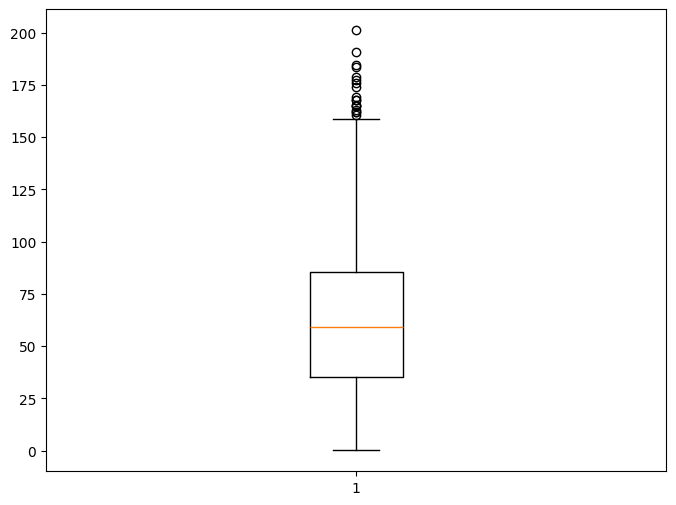

In [38]:
plt.figure(figsize=(8,6))

plt.boxplot(df_trips["duration_min"].dropna())

plt.show()

In [39]:
# Calculating Q1 & Q3

Q1 = df_trips["duration_min"].quantile(0.25)
Q3 = df_trips["duration_min"].quantile(0.75)
IQR = Q3 - Q1

print(f"Q1 (25th Percentile): {Q1}")
print(f"Q3 (75th Percentile): {Q3}")
print("IQR (Q3 - Q1): ", IQR)

Q1 (25th Percentile): 35.415
Q3 (75th Percentile): 85.375
IQR (Q3 - Q1):  49.96


In [40]:
# Calculating fenses (Upper & Lower)
lower_fence = Q1 - 1.5 * IQR
upper_fence = Q3 + 1.5 *IQR

print(f"Lower Fence: {lower_fence} (Outliers below this)")
print(f"Upper Fence: {upper_fence} (Outliers above this)")

Lower Fence: -39.525 (Outliers below this)
Upper Fence: 160.315 (Outliers above this)


In [41]:
# Identifying outliers 

outlier_mask = (df_trips["duration_min"] < lower_fence) | (df_trips["duration_min"] > upper_fence)
print(f"\nOutliers in {"duration_min"}:")
print(df[outlier_mask][["trip_id","rider_id","duration_min"]])

data_mask = (df_trips["duration_min"] > lower_fence) | (df_trips["duration_min"] < upper_fence)
print(f"\nGenuine Data in {"duration_min"}:")
print(df[data_mask][["trip_id","rider_id","duration_min"]])


Outliers in duration_min:
     trip_id rider_id  duration_min
57    T00058    R0020        161.83
185   T00186    R0222        173.85
290   T00291    R0169        164.64
343   T00344    R0036        161.82
425   T00426    R0177        167.72
431   T00432    R0075        178.53
550   T00551    R0121        190.53
754   T00755    R0029        165.01
1064  T01065    R0092        184.53
1168  T01169    R0241        160.35
1176  T01177    R0253        169.04
1348  T01349    R0023        162.72
1357  T01358    R0118        183.60
1694  T01695    R0028        165.21
1768  T01769    R0057        177.45
1773  T01774    R0233        175.96
1890  T01891    R0033        167.79
1893  T01894    R0093        201.07

Genuine Data in duration_min:
     trip_id rider_id  duration_min
0     T00001    R0037         74.59
1     T00002    R0104         35.59
2     T00003    R0045         31.03
3     T00004    R0089         59.48
4     T00005    R0003         67.59
...      ...      ...           ...
1995  

In [42]:
# Removing outliers

trips_clean_iqr = df_trips[~outlier_mask].copy()

print(f"Rows before: {len(df_trips)} | Rows after: {len(trips_clean_iqr)}")
print(f"Outliers removed: {outlier_mask.sum()}")
print(f"\nMean 'duration_min' before: {df_trips["duration_min"].mean()}")
print(f"\nMean 'duration_min' after: {trips_clean_iqr["duration_min"].mean()}")

Rows before: 2000 | Rows after: 1982
Outliers removed: 18

Mean 'duration_min' before: 61.883410000000005

Mean 'duration_min' after: 60.87546417759838


In [43]:
trips_clean_iqr

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,Z-Score (fare_amount),Z-Score (distance_km)
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,-0.347517,0.804911
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1,-1.100540,-0.985737
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1,-1.031435,-0.797011
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0,1.438690,0.631912
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1,-0.723327,-0.217354
...,...,...,...,...,...,...,...,...,...,...,...
1995,T01996,R0171,Zone_6,0.91,6.44,22.12,UPI,2023-03-20,0,-1.315222,-1.648523
1996,T01997,R0287,Zone_5,11.40,103.03,193.75,Cash,2024-06-25,1,0.691631,0.708301
1997,T01998,R0254,Zone_9,4.94,39.32,58.45,Cash,2024-03-23,0,-0.890419,-0.743089
1998,T01999,R0267,Zone_2,7.76,51.43,74.92,UPI,2023-10-29,1,-0.697837,-0.109510


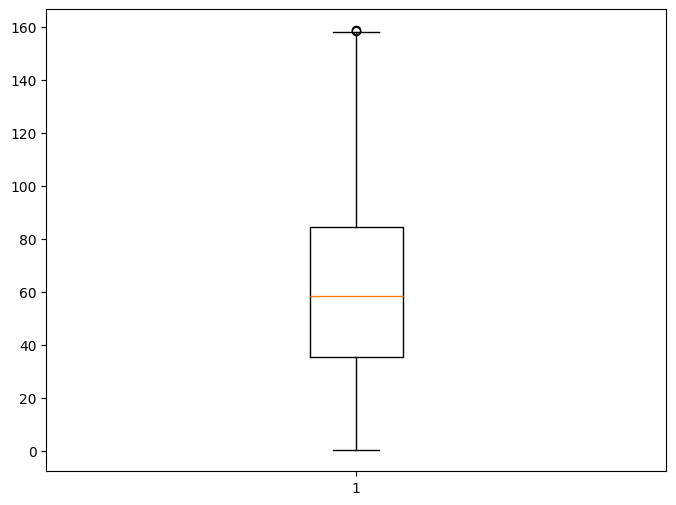

In [44]:
plt.figure(figsize=(8,6))

plt.boxplot(trips_clean_iqr["duration_min"].dropna())

plt.show()

- Apply Winsorization where necessary (e.g., extreme surge fares).

In [45]:
lower = df_riders["total_rides"].quantile(0.05)
upper = df_riders["total_rides"].quantile(0.95)

print(f"5th Percentile: {lower}")
print(f"95th Percentile: {upper}")

df_riders["total_rides_winsorized"] = df_riders["total_rides"].clip(lower=lower, upper=upper)

print("After Winsorization (clip):")
print(df_riders["total_rides_winsorized"])

5th Percentile: 29.950000000000003
95th Percentile: 477.05
After Winsorization (clip):
0       56.0
1       70.0
2       45.0
3      464.0
4      294.0
       ...  
295    390.0
296    396.0
297     65.0
298    457.0
299    291.0
Name: total_rides_winsorized, Length: 300, dtype: float64


- Before vs After comparison

In [46]:
print("========== BEFORE vs AFTER: Z-SCORE ==========")

print("\nFare Amount:")
print("Before Mean:", df_trips["fare_amount"].mean())
print("After Mean :", trips_clean["fare_amount"].mean())

print("Before Min :", df_trips["fare_amount"].min())
print("After Min  :", trips_clean["fare_amount"].min())

print("Before Max :", df_trips["fare_amount"].max())
print("After Max  :", trips_clean["fare_amount"].max())


print("\nDistance:")
print("Before Mean:", df_trips["distance_km"].mean())
print("After Mean :", trips_clean["distance_km"].mean())

print("Before Min :", df_trips["distance_km"].min())
print("After Min  :", trips_clean["distance_km"].min())

print("Before Max :", df_trips["distance_km"].max())
print("After Max  :", trips_clean["distance_km"].max())

========== BEFORE vs AFTER: Z-SCORE ==========

Fare Amount:
Before Mean: 134.600375
After Mean : 131.93204442200908
Before Min : 0.25
After Min  : 0.25
Before Max : 472.29
After Max  : 390.78

Distance:
Before Mean: 8.24742
After Mean : 8.141463907117618
Before Min : 0.02
After Min  : 0.02
Before Max : 25.86
After Max  : 20.8


In [47]:
print("========== BEFORE vs AFTER: IQR ==========")

print("Ride Duration:")

print("Before Mean:", df_trips["duration_min"].mean())
print("After Mean :", trips_clean_iqr["duration_min"].mean())

print("Before Min :", df_trips["duration_min"].min())
print("After Min  :", trips_clean_iqr["duration_min"].min())

print("Before Max :", df_trips["duration_min"].max())
print("After Max  :", trips_clean_iqr["duration_min"].max())

print("Before Rows:", len(df_trips))
print("After Rows :", len(trips_clean_iqr))

print("Outliers Removed:", len(df_trips) - len(trips_clean_iqr))

========== BEFORE vs AFTER: IQR ==========
Ride Duration:
Before Mean: 61.883410000000005
After Mean : 60.87546417759838
Before Min : 0.19
After Min  : 0.19
Before Max : 201.07
After Max  : 158.79
Before Rows: 2000
After Rows : 1982
Outliers Removed: 18


In [48]:
print("========== BEFORE vs AFTER: WINSORIZATION ==========")

print("Surge Fare:")

print("Before Mean:", df_riders["total_rides"].mean())

print("After Mean:", df_riders["total_rides_winsorized"].mean())

print("Before Min:", df_riders["total_rides"].min())

print("After Min:", df_riders["total_rides_winsorized"].min())

print("Before Max:", df_riders["total_rides"].max())

print("After Max:", df_riders["total_rides_winsorized"].max())

========== BEFORE vs AFTER: WINSORIZATION ==========
Surge Fare:
Before Mean: 244.69
After Mean: 244.88666666666666
Before Min: 4.0
After Min: 29.950000000000003
Before Max: 499.0
After Max: 477.05


In [49]:
comparison = pd.DataFrame({
    "Metric": ["Rows","Fare Mean","Fare Min",
               "Fare Max","Distance Mean",
               "Distance Min","Distance Max"],

    "Before": [len(df_trips),
               df_trips["fare_amount"].mean(),
               df_trips["fare_amount"].min(),
               df_trips["fare_amount"].max(),
               df_trips["distance_km"].mean(),
               df_trips["distance_km"].min(),
               df_trips["distance_km"].max()],

    "After": [len(trips_clean),
              trips_clean["fare_amount"].mean(),
              trips_clean["fare_amount"].min(),
              trips_clean["fare_amount"].max(),
              trips_clean["distance_km"].mean(),
              trips_clean["distance_km"].min(),
              trips_clean["distance_km"].max()]})

print(comparison)

          Metric       Before        After
0           Rows  2000.000000  1981.000000
1      Fare Mean   134.600375   131.932044
2       Fare Min     0.250000     0.250000
3       Fare Max   472.290000   390.780000
4  Distance Mean     8.247420     8.141464
5   Distance Min     0.020000     0.020000
6   Distance Max    25.860000    20.800000


### Task-4 : Data Transformation

##### I. Convert datetime → hour, day_of_week, month

In [50]:
df_riders["hour"] = df_riders["signup_date"].dt.hour
df_riders["day_of_week"] = df_riders["signup_date"].dt.day_name()
df_riders["month"] = df_riders["signup_date"].dt.month
df_riders["year"] = df_riders["signup_date"].dt.year

In [51]:
df_riders[["hour","day_of_week","month","year"]]

,hour,day_of_week,month,year
0,0,Monday,6,2020
1,0,Saturday,11,2019
2,0,Thursday,5,2023
3,0,Sunday,7,2019
4,0,Monday,5,2021
...,...,...,...,...
295,0,Saturday,2,2021
296,0,Wednesday,9,2023
297,0,Wednesday,3,2020
298,0,Friday,9,2020


##### II. Encode categorical columns:

- Label Encode: gender

In [52]:
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()

df_riders["gender_enc"] = label_enc.fit_transform(df_riders["gender"])

print("--- Target variable (gender) encoded ---")
print(f"Classes: {label_enc.classes_}")
print(f"Mapping: Female → {label_enc.transform(["Female"])[0]}, Male → {label_enc.transform(["Male"])[0]}")
print(df_riders[["gender", "gender_enc"]])

--- Target variable (gender) encoded ---
Classes: ['Female' 'Male' 'Other']
Mapping: Female → 0, Male → 1
     gender  gender_enc
0      Male           1
1    Female           0
2      Male           1
3     Other           2
4      Male           1
..      ...         ...
295   Other           2
296    Male           1
297  Female           0
298   Other           2
299  Female           0

[300 rows x 2 columns]


- One-Hot Encode: ride_payment_mode, zone_name

In [53]:
from sklearn.preprocessing import OneHotEncoder

ohe_cols = ["payment_mode", "zone"]

ohe_enc = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

ohe_arr = ohe_enc.fit_transform(df_trips[ohe_cols])

feature_names = ohe_enc.get_feature_names_out(ohe_cols)

trips_ohe = pd.DataFrame(ohe_arr, columns=feature_names)

print("---- sklearn OneHotEncoder ----")
print(trips_ohe.head())
print("\nGenerated feature names: ",feature_names.tolist())


---- sklearn OneHotEncoder ----
   payment_mode_Credit Card  payment_mode_UPI  payment_mode_Wallet  \
0                       0.0               0.0                  0.0   
1                       0.0               0.0                  0.0   
2                       0.0               0.0                  0.0   
3                       0.0               0.0                  0.0   
4                       0.0               1.0                  0.0   

   zone_Zone_10  zone_Zone_2  zone_Zone_3  zone_Zone_4  zone_Zone_5  \
0           1.0          0.0          0.0          0.0          0.0   
1           0.0          0.0          0.0          0.0          0.0   
2           0.0          0.0          0.0          0.0          0.0   
3           0.0          1.0          0.0          0.0          0.0   
4           0.0          0.0          0.0          0.0          1.0   

   zone_Zone_6  zone_Zone_7  zone_Zone_8  zone_Zone_9  
0          0.0          0.0          0.0          0.0  
1       

- Ordinal Encode: traffic_level (Low < Medium < High)

In [54]:
def traffic_level(x):
    if x <= 1:
        return "Low"
    if x <= 2:
        return "Medium"
    else:
        return "High"
    

df_zones["traffic_level"] = df_zones["traffic_index"].apply(traffic_level)

In [55]:
from sklearn.preprocessing import OrdinalEncoder

ordinal_enc = OrdinalEncoder(categories=[['Low', 'Medium', 'High']])

ordinal_zones = df_zones[["traffic_level"]].copy()

df_zones["ordinal_traffic_index"] = ordinal_enc.fit_transform(ordinal_zones)

print("Ordinal Encoding with sklearn")
print(df_zones[["traffic_level", "ordinal_traffic_index"]])

Ordinal Encoding with sklearn
  traffic_level  ordinal_traffic_index
0          High                    2.0
1           Low                    0.0
2          High                    2.0
3          High                    2.0
4        Medium                    1.0


##### III. Binning:

- Customer ride frequency (Low/Med/High)

In [56]:
def ride_frequency (x):
    
    if x < 50:
        return "Low"
    
    elif x < 150:
        return "Med"
    
    else:
        return "High"
    
    
df_riders["ride_frequency"] = df_riders["total_rides"].apply(ride_frequency)

print(df_riders[['total_rides', 'ride_frequency']])

     total_rides ride_frequency
0           56.0            Med
1           70.0            Med
2           45.0            Low
3          464.0           High
4          294.0           High
..           ...            ...
295        390.0           High
296        396.0           High
297         65.0            Med
298        457.0           High
299        291.0           High

[300 rows x 2 columns]


##### IV. Transform skewed numeric columns:

- Log transform on fare and distance

In [57]:
from sklearn.preprocessing import FunctionTransformer

print("Comparison of skewness ('fare_amount')")
print(f"Original skewness : {df_trips['fare_amount'].skew()}")

log_trans_fare = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)

df_trips["log_transform_fare"] = log_trans_fare.fit_transform(df_trips[["fare_amount"]])

print(f"Log transform skewness : {df_trips['log_transform_fare'].skew()}")

print(df_trips[['fare_amount', 'log_transform_fare']])

Comparison of skewness ('fare_amount')
Original skewness : 0.7740395664182473
Log transform skewness : -1.5149707900395364
      fare_amount  log_transform_fare
0          104.88            4.662306
1           40.48            3.725211
2           46.39            3.858411
3          257.64            5.555437
4           72.74            4.300545
...           ...                 ...
1995        22.12            3.140698
1996       193.75            5.271717
1997        58.45            4.085136
1998        74.92            4.329680
1999       149.05            5.010969

[2000 rows x 2 columns]


In [58]:
print("Comparison of skewness ('distance_km')")
print(f"Original skewness : {df_trips['distance_km'].skew()}")

log_trans_fare = FunctionTransformer(func=np.log1p, inverse_func=np.expm1)

df_trips["log_transform_dis"] = log_trans_fare.fit_transform(df_trips[["distance_km"]])

print(f"Log transform skewness : {df_trips['log_transform_dis'].skew()}")

print(df_trips[['distance_km', 'log_transform_dis']])

Comparison of skewness ('distance_km')
Original skewness : 0.2305683925892567
Log transform skewness : -1.0895583124226218


      distance_km  log_transform_dis
0           11.83           2.551786
1            3.86           1.581038
2            4.70           1.740466
3           11.06           2.489894
4            7.28           2.113843
...           ...                ...
1995         0.91           0.647103
1996        11.40           2.517696
1997         4.94           1.781709
1998         7.76           2.170196
1999        12.02           2.566487

[2000 rows x 2 columns]


- Square-root transform on duration

In [59]:
sqrt_transform = FunctionTransformer(func=np.sqrt, inverse_func=np.square)

df_trips["sqrt_duration"] = sqrt_transform.transform(df_trips[["duration_min"]])

df_trips["restored_duration"] = sqrt_transform.inverse_transform(df_trips[["sqrt_duration"]]).round(0)

df_trips[["trip_id", "duration_min", "sqrt_duration", "restored_duration"]]


,trip_id,duration_min,sqrt_duration,restored_duration
0,T00001,74.59,8.636550,75.0
1,T00002,35.59,5.965735,36.0
2,T00003,31.03,5.570458,31.0
3,T00004,59.48,7.712328,59.0
4,T00005,67.59,8.221314,68.0
...,...,...,...,...
1995,T01996,6.44,2.537716,6.0
1996,T01997,103.03,10.150369,103.0
1997,T01998,39.32,6.270566,39.0
1998,T01999,51.43,7.171471,51.0


### Task-5 : Feature Scaling

- Scale numeric features using:

In [60]:
## StandardScaler

from sklearn.preprocessing import StandardScaler

scale_cols = ["fare_amount", "distance_km", "duration_min"]

std_scaler = StandardScaler()

trips_std_scale = pd.DataFrame(std_scaler.fit_transform(df_trips[scale_cols]), 
                               columns = [c + "_stdscale" for c in scale_cols], 
                               index = df_trips.index)

In [61]:
print("----- StandardScaler -----")

print("\nBefore scaling:")
print(df_trips[scale_cols].agg(["mean", "median", "std", "min", "max"]))

print("\nAfter scaling:")
print(trips_std_scale.agg(["mean", "median", "std", "min", "max"]))


----- StandardScaler -----

Before scaling:
        fare_amount  distance_km  duration_min
mean     134.600375     8.247420     61.883410
median   121.850000     8.115000     58.950000
std       85.521989     4.450904     35.980603
min        0.250000     0.020000      0.190000
max      472.290000    25.860000    201.070000

After scaling:
        fare_amount_stdscale  distance_km_stdscale  duration_min_stdscale
mean           -1.616485e-16          5.329071e-18          -1.172396e-16
median         -1.491261e-01         -2.975870e-02          -8.154793e-02
std             1.000250e+00          1.000250e+00           1.000250e+00
min            -1.571338e+00         -1.848945e+00          -1.715058e+00
max             3.949558e+00          3.958069e+00           3.869346e+00


In [62]:
### MinMaxScaler

from sklearn.preprocessing import MinMaxScaler

minmax_scaler = MinMaxScaler()

trips_minmax_scale = pd.DataFrame(minmax_scaler.fit_transform(df_trips[scale_cols]),
                                  columns = [c + "_standard" for c in scale_cols],
                                  index = df_trips.index)

In [63]:
print("----- StandardScaler -----")

print("\nBefore scaling:")
print(df_trips[scale_cols].agg(["mean", "median", "std", "min", "max"]))

print("\nAfter scaling:")
print(trips_minmax_scale.agg(["mean", "median", "std", "min", "max"]))


----- StandardScaler -----

Before scaling:
        fare_amount  distance_km  duration_min
mean     134.600375     8.247420     61.883410
median   121.850000     8.115000     58.950000
std       85.521989     4.450904     35.980603
min        0.250000     0.020000      0.190000
max      472.290000    25.860000    201.070000

After scaling:
        fare_amount_standard  distance_km_standard  duration_min_standard
mean                0.284617              0.318399               0.307116
median              0.257605              0.313274               0.292513
std                 0.181175              0.172249               0.179115
min                 0.000000              0.000000               0.000000
max                 1.000000              1.000000               1.000000


### Task-6 : Feature Construction

##### I. Engineer useful ML-ready features:

In [64]:
ride_summary = df_trips.groupby("rider_id").agg(
    total_distance=("distance_km", "sum"),
    total_fare = ("fare_amount", "sum"),
    total_trips = ("trip_id", "count")
).reset_index()

print(ride_summary.head(10))

  rider_id  total_distance  total_fare  total_trips
0    R0001           20.84      317.57            2
1    R0002           75.69     1175.61            7
2    R0003           67.68      971.71           10
3    R0004           37.21      683.03            6
4    R0005           51.26      926.45            7
5    R0006           63.24     1095.43            7
6    R0007           39.62      596.92            6
7    R0008           48.25      893.27            8
8    R0009           64.88      916.39            7
9    R0010           85.25     1204.51            9


In [65]:
# Merge ride_summary with df_riders

df_riders = df_riders.merge(ride_summary,
                            on="rider_id",
                            how="left")

- avg_ride_distance (total distance / total trips)



In [66]:
df_riders["avg_ride_distance"] = (df_riders["total_distance"]/df_riders["total_trips"])

- avg_ride_fare (total fare / rides)



In [67]:
df_riders["avg_ride_fare"] = (df_riders["total_fare"]/df_riders["total_rides"])

- is_peak_hour (1 if hour in [7-9, 18-21] else 0)



In [68]:
df_riders["is_peak_hour"] = df_riders["hour"].apply(
                            lambda x: 1 if x in [7,8,9,18,19,20,21]
                            else 0
)

- days_since_signup (today − signup_date)



In [69]:
df_riders["days_since_signup"] = (pd.Timestamp.today() - df_riders["signup_date"]).dt.days

- ride_cancellation_rate (cancelled_rides / total_rides)



In [70]:
df_riders["ride_cancellation_rate"] = df_riders["cancelled_rides"]/df_riders["total_rides"]

- surge_flag (1 if fare/distance > threshold)



In [71]:
df_trips["fare_per_km"] = (df_trips["fare_amount"]/df_trips["distance_km"])

threshold_fpk = df_trips["fare_per_km"].quantile(0.90)

df_trips["surge_flag"] = df_trips["fare_per_km"].apply(
                         lambda x: 1 if x > threshold_fpk
                         else 0)

In [72]:
df_riders.head()

,rider_id,name,age,gender,city,signup_date,total_rides,cancelled_rides,avg_rating,total_rides_winsorized,...,gender_enc,ride_frequency,total_distance,total_fare,total_trips,avg_ride_distance,avg_ride_fare,is_peak_hour,days_since_signup,ride_cancellation_rate
0,R0001,Aarav Das,23,Male,Pune,2020-06-29,56.0,0,3.76,56.0,...,1,Med,20.84,317.57,2.0,10.420000,5.670893,0,2271,0.000000
1,R0002,Ishaan Nair,39,Female,Mumbai,2019-11-23,70.0,5,4.12,70.0,...,0,Med,75.69,1175.61,7.0,10.812857,16.794429,0,2490,0.071429
2,R0003,Kavya Reddy,34,Male,Pune,2023-05-04,45.0,9,3.76,45.0,...,1,Low,67.68,971.71,10.0,6.768000,21.593556,0,1232,0.200000
3,R0004,Aarav Nair,19,Other,Kolkata,2019-07-28,464.0,5,3.19,464.0,...,2,High,37.21,683.03,6.0,6.201667,1.472047,0,2608,0.010776
4,R0005,Diya Reddy,27,Male,Ahmedabad,2021-05-31,294.0,30,3.53,294.0,...,1,High,51.26,926.45,7.0,7.322857,3.151190,0,1935,0.102041


In [73]:
df_trips.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,Z-Score (fare_amount),Z-Score (distance_km),log_transform_fare,log_transform_dis,sqrt_duration,restored_duration,fare_per_km
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,-0.347517,0.804911,4.662306,2.551786,8.636550,75.0,8.865596
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,0,-1.100540,-0.985737,3.725211,1.581038,5.965735,36.0,10.487047
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,0,-1.031435,-0.797011,3.858411,1.740466,5.570458,31.0,9.870213
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,1,1.438690,0.631912,5.555437,2.489894,7.712328,59.0,23.294756
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,0,-0.723327,-0.217354,4.300545,2.113843,8.221314,68.0,9.991758


### Task-7 : Final Dataset

- Merge cleaned & enriched datasets

In [74]:
trips_clean

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,1
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,1
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,1
...,...,...,...,...,...,...,...,...,...
1995,T01996,R0171,Zone_6,0.91,6.44,22.12,UPI,2023-03-20,0
1996,T01997,R0287,Zone_5,11.40,103.03,193.75,Cash,2024-06-25,1
1997,T01998,R0254,Zone_9,4.94,39.32,58.45,Cash,2024-03-23,0
1998,T01999,R0267,Zone_2,7.76,51.43,74.92,UPI,2023-10-29,1


In [81]:
final_dataset = df_trips.merge(
                df_riders[[
                    "rider_id",
                    "age",
                    "gender",
                    "city",
                    "total_rides",
                    "cancelled_rides",
                    "avg_rating",
                    "avg_ride_distance",
                    "avg_ride_fare",
                    "days_since_signup",
                    "ride_cancellation_rate"
                ]],
                on="rider_id",
                how="left"
)

final_dataset.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,Z-Score (fare_amount),...,age,gender,city,total_rides,cancelled_rides,avg_rating,avg_ride_distance,avg_ride_fare,days_since_signup,ride_cancellation_rate
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,-0.347517,...,32,Other,Ahmedabad,489.0,6,3.36,9.761250,2.688466,2126,0.012270
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,0,-1.100540,...,52,Male,Kolkata,328.0,1,3.70,5.187778,2.333506,1939,0.003049
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,0,-1.031435,...,34,Other,Ahmedabad,100.0,16,4.88,9.725556,15.298500,1163,0.160000
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,1,1.438690,...,48,Other,Surat,308.0,6,3.91,9.981111,4.595942,1457,0.019481
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,0,-0.723327,...,34,Male,Pune,45.0,9,3.76,6.768000,21.593556,1232,0.200000


In [82]:
final_dataset = final_dataset.merge(
                df_zones[[
                    "zone_name",
                    "population_density",
                    "traffic_index",
                    "avg_speed_kmph",
                    "zone_type",
                    "traffic_level",
                    "ordinal_traffic_index"
                ]],
                left_on = "zone",
                right_on="zone_name",
                how="left"
)


final_dataset.head()

,trip_id,rider_id,zone,distance_km,duration_min,fare_amount,payment_mode,ride_date,surge_flag,Z-Score (fare_amount),...,avg_ride_fare,days_since_signup,ride_cancellation_rate,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type,traffic_level,ordinal_traffic_index
0,T00001,R0037,Zone_10,11.83,74.59,104.88,Cash,2023-11-13,0,-0.347517,...,2.688466,2126,0.012270,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,T00002,R0104,Zone_9,3.86,35.59,40.48,Cash,2023-07-28,0,-1.100540,...,2.333506,1939,0.003049,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,T00003,R0045,Zone_8,4.70,31.03,46.39,Cash,2024-01-14,0,-1.031435,...,15.298500,1163,0.160000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,T00004,R0089,Zone_2,11.06,59.48,257.64,Cash,2023-12-13,1,1.438690,...,4.595942,1457,0.019481,Zone_2,6371.0,0.91,58.4,Residential,Low,0.0
4,T00005,R0003,Zone_5,7.28,67.59,72.74,UPI,2023-03-15,0,-0.723327,...,21.593556,1232,0.200000,Zone_5,2590.0,1.31,43.9,Business,Medium,1.0


In [83]:
print("Final Dataset Shape:", final_dataset.shape)

print("\nFinal Dataset Columns:")
print(final_dataset.columns.tolist())

Final Dataset Shape: (2000, 33)

Final Dataset Columns:
['trip_id', 'rider_id', 'zone', 'distance_km', 'duration_min', 'fare_amount', 'payment_mode', 'ride_date', 'surge_flag', 'Z-Score (fare_amount)', 'Z-Score (distance_km)', 'log_transform_fare', 'log_transform_dis', 'sqrt_duration', 'restored_duration', 'fare_per_km', 'age', 'gender', 'city', 'total_rides', 'cancelled_rides', 'avg_rating', 'avg_ride_distance', 'avg_ride_fare', 'days_since_signup', 'ride_cancellation_rate', 'zone_name', 'population_density', 'traffic_index', 'avg_speed_kmph', 'zone_type', 'traffic_level', 'ordinal_traffic_index']


- Produce summary table:
    - Rows before vs after cleaning
    - Missing values before vs after
    - Outliers before vs after
    - of new engineered features


In [84]:
rows_before = len(df_trips)
rows_after = len(trips_clean)

print("Rows before cleaning: ", rows_before)
print("Rows after cleaning: ", rows_after)

Rows before cleaning:  2000
Rows after cleaning:  1981


In [87]:
missing_before = df_trips.isnull().sum().sum()
missing_after = final_dataset.isnull().sum().sum()

print("Missing values before:", missing_before)
print("Missing values after:", missing_after)

Missing values before: 0
Missing values after: 6776


In [91]:
outliers_before = (
    (df_trips["Z-Score (fare_amount)"].abs() > 3).sum()
    +
    (df_trips["Z-Score (distance_km)"].abs() > 3).sum()
)

outliers_after = (
    (trips_clean["fare_amount"] > trips_clean["fare_amount"].mean() + 3 * trips_clean["fare_amount"].std()).sum()
    +
    (trips_clean["distance_km"] > trips_clean["distance_km"].mean() + 3 * trips_clean["distance_km"].std()).sum()
)

In [89]:
new_features = [
    "avg_ride_distance",
    "avg_ride_fare",
    "is_peak_hour",
    "days_since_signup",
    "ride_cancellation_rate",
    "surge_flag"
]

print("Number of new engineered features:", len(new_features))
print("\nNew Engineered Features:")
print(new_features)

Number of new engineered features: 6

New Engineered Features:
['avg_ride_distance', 'avg_ride_fare', 'is_peak_hour', 'days_since_signup', 'ride_cancellation_rate', 'surge_flag']


In [92]:
### Final summary table

summary_table = pd.DataFrame({
    "Metric": [
        "Rows",
        "Missing Values",
        "Outliers"
    ],
    "Before Cleaning": [
        rows_before,
        missing_before,
        outliers_before
    ],
    "After Cleaning": [
        rows_after,
        missing_after,
        outliers_after
    ]
})

display(summary_table)

,Metric,Before Cleaning,After Cleaning
0,Rows,2000,1981
1,Missing Values,0,6776
2,Outliers,19,7


In [93]:
engineered_features_table = pd.DataFrame({
    "Engineered Feature": new_features
})

display(engineered_features_table)

,Engineered Feature
0,avg_ride_distance
1,avg_ride_fare
2,is_peak_hour
3,days_since_signup
4,ride_cancellation_rate
5,surge_flag


In [79]:
df_zones.head()

,zone_name,population_density,traffic_index,avg_speed_kmph,zone_type,traffic_level,ordinal_traffic_index
0,Zone_1,4921,2.43,30.9,Residential,High,2.0
1,Zone_2,6371,0.91,58.4,Residential,Low,0.0
2,Zone_3,12971,2.11,38.0,Business,High,2.0
3,Zone_4,4038,2.46,48.2,Business,High,2.0
4,Zone_5,2590,1.31,43.9,Business,Medium,1.0


In [94]:
final_dataset.to_csv(
    "final_prepared_rides_dataset.csv",
    index=False
)

print("Final dataset exported successfully!")

Final dataset exported successfully!


### Task-8 : Bonus (Optional)

##### I. Auto-generate Pandas/YData Profiling EDA report

In [95]:
from ydata_profiling import ProfileReport

profile = ProfileReport(
    final_dataset,
    title="Final Prepared Rides Dataset - EDA Report",
    explorative=True
)

profile.to_file("rides_eda_report.html")

print("EDA report generated successfully!")

ModuleNotFoundError: No module named 'ydata_profiling'

- Visualization for:
    - Ride demand by hour
    - Surge vs No-Surge trip patterns


In [100]:
# ----- Ride Demand by Hour -----

ride_demand = df_riders.groupby("hour").size().reset_index(
    name="ride_count"
)

print(ride_demand)

   hour  ride_count
0     0         300


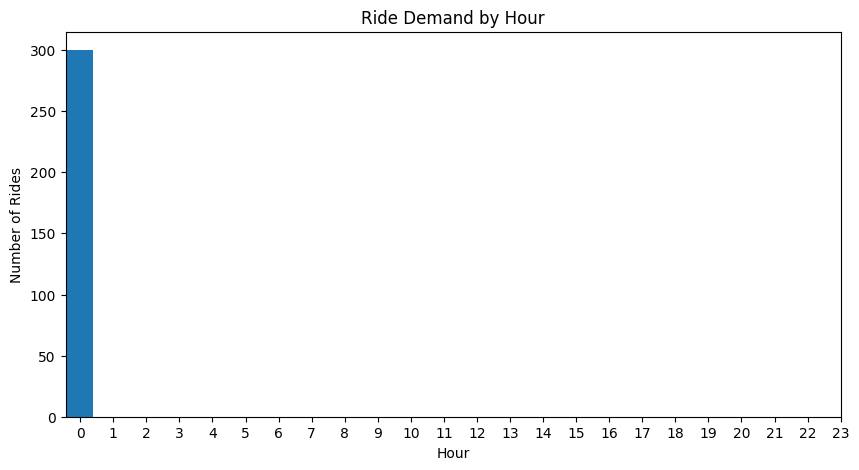

In [101]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.bar(
    ride_demand["hour"],
    ride_demand["ride_count"]
)

plt.xlabel("Hour")
plt.ylabel("Number of Rides")
plt.title("Ride Demand by Hour")

plt.xticks(range(24))

plt.show()

In [99]:
# ----- Surge vs No-Surge Trips -----

surge_counts = df_trips["surge_flag"].value_counts().sort_index()

print(surge_counts)

surge_flag
0    1800
1     200
Name: count, dtype: int64


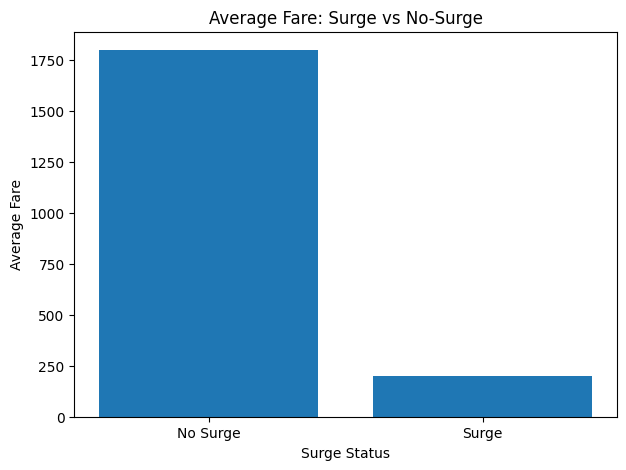

In [106]:
plt.figure(figsize=(7, 5))

plt.bar(
    ["No Surge", "Surge"],
    [
        surge_counts.get(0, 0),
        surge_counts.get(1, 0)
    ]
)

plt.xlabel("Surge Status")
plt.ylabel("Average Fare")
plt.title("Average Fare: Surge vs No-Surge")

plt.show()